In [276]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scienceplots

N = 200                 #number of oscillators
K1 = 1.5
K2 = 2
K3 = 3                 #coupling strengths
t_span = (0, 50)
t_eval = np.linspace(*t_span, 2000)

# Gaussian
omega = np.random.normal(0, 1, N)

theta0 = np.random.uniform(0, 2*np.pi, N)

def kuramoto(t, theta, K):

    theta_i = theta[:, None]
    theta_j = theta[None, :]

    coupling = np.sum(np.sin(theta_j - theta_i), axis=1)

    return omega + (K/N) * coupling

sol1 = solve_ivp(kuramoto, t_span, theta0, t_eval=t_eval, args=(K1,))
sol2 = solve_ivp(kuramoto, t_span, theta0, t_eval=t_eval, args=(K2,))
sol3 = solve_ivp(kuramoto, t_span, theta0, t_eval=t_eval, args=(K3,))

theta1 = sol1.y
theta2 = sol2.y
theta3 = sol3.y

In [277]:
r1 = np.abs(np.mean(np.exp(1j*theta1), axis=0))
r2 = np.abs(np.mean(np.exp(1j*theta2), axis=0))
r3 = np.abs(np.mean(np.exp(1j*theta3), axis=0))

In [278]:
print(r1[-1], r2[-1], r3[-1])

0.41968571562019585 0.7677120621075786 0.9365992973100279


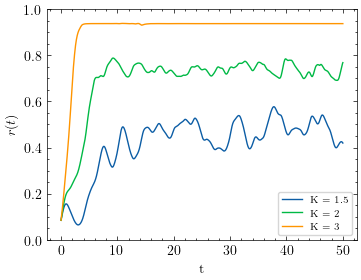

In [283]:
plt.style.use('science')
plt.figure(figsize=(4,3))
plt.plot(sol1.t, r1, label="K = 1.5")
plt.plot(sol2.t, r2, label="K = 2")
plt.plot(sol3.t, r3, label="K = 3")
plt.xlabel("t")
plt.ylabel("$r(t)$")
plt.ylim(0,1)
plt.legend(fontsize= 7,frameon=True)
plt.show()

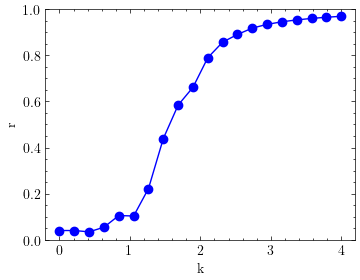

In [280]:
K_values = np.linspace(0,4,20)
r_final = []

for K in K_values:

    sol = solve_ivp(kuramoto, t_span, theta0, t_eval=t_eval, args=(K,))
    theta = sol.y
    r = np.abs(np.mean(np.exp(1j*theta), axis=0))

    r_final.append(np.mean(r[-200:]))

plt.figure(figsize=(4,3))
plt.plot(K_values, r_final,'o-b')
plt.xlabel("k")
plt.ylabel("r")
plt.ylim(0,1)
plt.show()

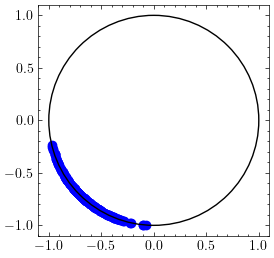

In [281]:
theta_final_phases = theta[:,-1]

plt.figure(figsize=(4,3))
plt.scatter(np.cos(theta_final_phases), np.sin(theta_final_phases), color = 'blue')
circle = plt.Circle((0,0),1,fill=False)
plt.gca().add_patch(circle)
plt.gca().set_aspect('equal')
plt.show()

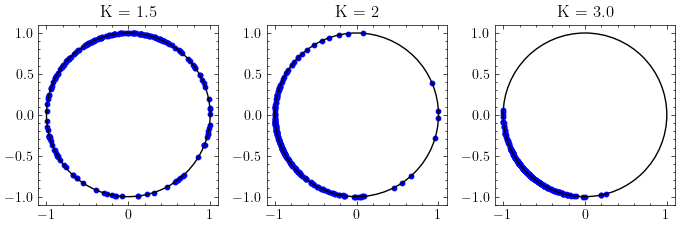

In [284]:
K_test = [1.5, 2, 3.0]

fig, axes = plt.subplots(1,3, figsize=(7,4))

for i, K in enumerate(K_test):

    sol = solve_ivp(kuramoto, t_span, theta0, t_eval=t_eval, args=(K,))

    theta = sol.y
    theta_final = theta[:,-1]

    ax = axes[i]
    ax.scatter(np.cos(theta_final), np.sin(theta_final), s=10, color='blue')
    circle = plt.Circle((0,0),1,fill=False)
    ax.add_patch(circle)
    ax.set_aspect('equal')
    ax.set_title(f"K = {K}")

plt.tight_layout()
plt.show()